In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def dispersion(kx, ky, eta = 1.):
    return 2 * ( np.cos(2*kx) + np.cos(2*ky) + 4 * np.cos(kx) * np.cos(ky) * np.cos(np.pi/2 * (1 - eta)) )

k_range = np.linspace(0, np.pi, 50, endpoint = False)

gxmg_path = []
# g - x
gxmg_path.extend( [ (k, 0) for k in k_range ] )
# x - m
gxmg_path.extend( [ (np.pi, k) for k in k_range ] )
# m - g
gxmg_path.extend( [ (np.pi - k, np.pi - k) for k in k_range ] )

def get_progress_along_path(k_point):
    kx, ky = k_point
    kx /= np.pi
    ky /= np.pi
    
    if ky == 0:
        return kx
    elif kx == 1.:
        return ky + 1
    elif kx == ky:
        return 2 + np.sqrt(2) * (1. - kx)

In [13]:
def plot_disp(eta = 1., offset = 0., color = 'b'):
    k_points = np.array(gxmg_path)
    k_path = np.zeros((k_points.shape[0] + 1, k_points.shape[1]))
    k_path[-1, :] = np.array([0, 0])
    k_path[:-1, :] = k_points
        
    # ---- Step 1: Build cumulative "distance" along the path ----
    dist = [] #[0.0]
        
    for k in k_path[:-1, :]:
        dist.append(get_progress_along_path(k))
    dist.append(2+np.sqrt(2))
    dist = np.array(dist)

    disp = dispersion(k_path[:, 0], k_path[:, 1], eta)

    en = 2 * np.sqrt((1 + offset)**2 + 1/4 - disp/16)

    plt.plot(dist, en, label = rf'$\eta = {eta}$', color = color)
    plt.xticks([0, 1., 2., 2.+np.sqrt(2)], [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'], rotation = 0)


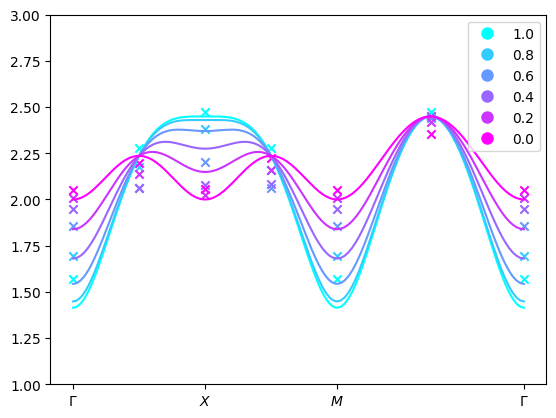

In [14]:
supercells = [
    '4x4', '6x4'
]

def get_rect_k_path(nx, ny):
    k_path = []
    
    k_x = [ 2*x/nx for x in range(int(nx/2)+1) ]
    for kx in k_x:
        k_path.append( np.array( [kx, 0] ) )
        
    k_y = [ 2*y/ny for y in range(1, int(ny/2)+1) ]
    
    for ky in k_y:
        k_path.append( np.array( [1, ky] ) )
        
    if nx == ny:
        for ky in (k_y[:-1]).__reversed__():
            k_path.append( np.array( [ky, ky] ) )
    
    return k_path

k_paths = {}

for sc in supercells:
    if sc.__contains__('x'):
        k_paths[sc] = get_rect_k_path(int(sc[0]), int(sc[-1]))

def plot_eta_dep(eta = 1., c='gray', alpha = .5):
    try:
        p_x = np.loadtxt(fr'data/d={1.}_l={0.}_e={eta}/{'4x4'}_S_+-_en.txt')
    except:
        if eta == 1.:
            p_x = np.loadtxt(fr'data/d={1.}_l={0.}/{'4x4'}_S_+-_en.txt')
        else:
            raise FileNotFoundError
    
    energy = np.zeros( ( p_x.shape[0], p_x.shape[1] + 1 ) )
    energy[:, :-1] = p_x
    energy[:, -1] = p_x[:, 0]
        
    k_points = np.array(k_paths['4x4'].copy())
    k_path = np.zeros((k_points.shape[0] + 1, k_points.shape[1]))
    k_path[-1, :] = np.array([0, 0])
    k_path[:-1, :] = k_points
        
    from fractions import Fraction
    
    # ---- Step 1: Build cumulative "distance" along the path ----
    dist = [] #[0.0]
    
    def _get_progress_along_path(k_point):
        kx, ky = k_point
        
        if ky == 0:
            return kx
        elif kx == 1.:
            return ky + 1
        elif kx == ky:
            return 2 + np.sqrt(2) * (1. - kx)

    for k in k_path[:-1, :]:
        dist.append(_get_progress_along_path(k))
    dist.append(2+np.sqrt(2))
    dist = np.array(dist)
        
    for ii in range(energy.shape[0]):
        for jj in range(energy.shape[1]):
            if ii == 0:
                plt.scatter( dist[jj], energy[ii, jj], color=c, alpha=alpha, marker = 'x')
            else:
                plt.scatter( dist[jj], energy[ii, jj], color=c, alpha=alpha, marker = '_')
        
    plt.ylim([1., 3.])
    
    return np.min(energy)


#fig = plt.figure(figsize = (8, 4), dpi = 200)

num = 6

cmap = plt.get_cmap('cool', num)

legend = []
from matplotlib.lines import Line2D

for ii in range(num):
    eta = round(1. - ii/(num - 1), 2)
    plot_eta_dep(eta = eta, c = cmap(ii), alpha = 1.)
    plot_disp(eta, offset = 0., color = cmap(ii))
    legend.append(Line2D([0], [0], marker='o', color='w', label=round(1. - ii/(num - 1), 2), markerfacecolor=cmap(ii), markersize=10, alpha=1.))

plt.legend(handles = legend, loc=1)
plt.show()


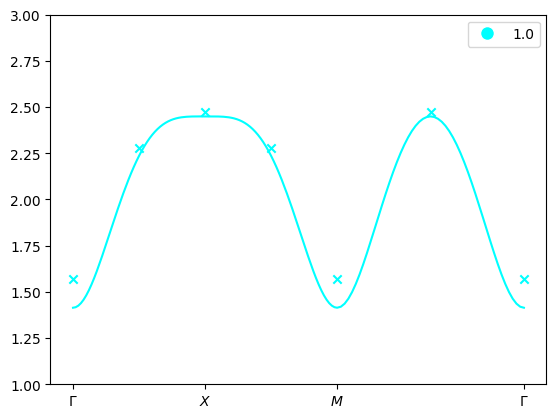

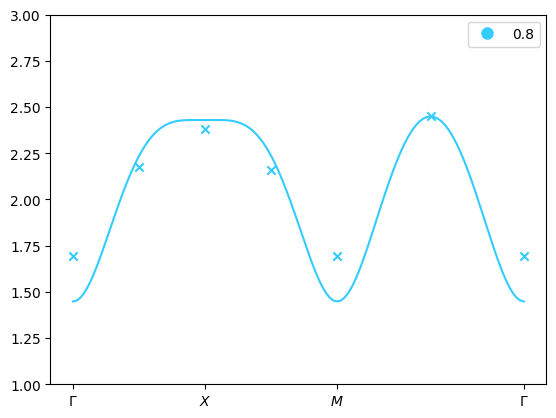

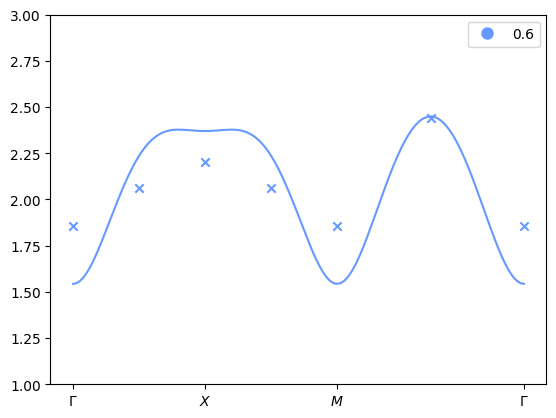

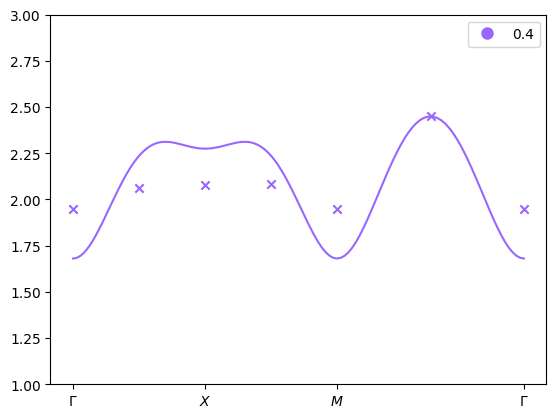

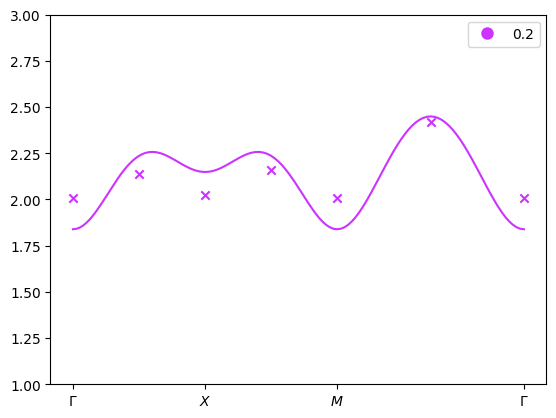

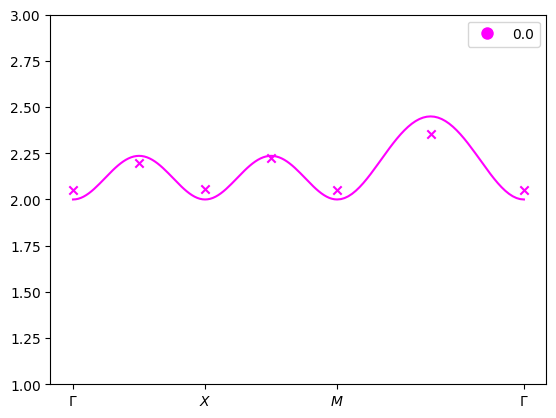

In [15]:
num = 6

cmap = plt.get_cmap('cool', num)

legend = []
from matplotlib.lines import Line2D

for ii in range(num):
    eta = round(1. - ii/(num - 1), 2)
    plot_eta_dep(eta = eta, c = cmap(ii), alpha = 1.)
    plot_disp(eta, offset = 0., color = cmap(ii))
    legend.append(Line2D([0], [0], marker='o', color='w', label=round(1. - ii/(num - 1), 2), markerfacecolor=cmap(ii), markersize=10, alpha=1.))
    plt.legend(handles = legend, loc=1)
    legend = []
    plt.show()


In [ ]:
def plot_cosines(eta = 1., offset = 0., color = 'b'):
    k_points = np.array(gxmg_path)
    k_path = np.zeros((k_points.shape[0] + 1, k_points.shape[1]))
    k_path[-1, :] = np.array([0, 0])
    k_path[:-1, :] = k_points
        
    # ---- Step 1: Build cumulative "distance" along the path ----
    dist = [] #[0.0]
        
    for k in k_path[:-1, :]:
        dist.append(get_progress_along_path(k))
    dist.append(2+np.sqrt(2))
    dist = np.array(dist)

    kx = k_path[:, 0]
    ky = k_path[:, 1]

    plt.plot(dist, np.cos(2*kx), label = rf'$\eta = {eta}$', color = color)
    plt.plot(dist, np.cos(2*ky), label = rf'$2y$', color = color)
    plt.plot(dist, 4 * np.cos(kx) * np.cos(ky), label = rf'$diag$', color = color)
    plt.xticks([0, 1., 2., 2.+np.sqrt(2)], [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'], rotation = 0)
    return 2 * ( np.cos(2*kx) + np.cos(2*ky) + 4 * np.cos(kx) * np.cos(ky) * np.cos(np.pi/2 * (1 - eta)) )
